# Test Single Sample — Diffusion Model Evaluation
Loads the trained checkpoint and runs the **reverse diffusion** (noise → image).
This fixed notebook correctly displays the denoised image at the end.

In [1]:
# ── Mount Drive (Colab only) ─────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/My Drive/assignment5')

Mounted at /content/drive


In [2]:
# ── Imports ──────────────────────────────────────────────────────────
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

# UNet and GaussianDiffusion live inside your training script
from MSDS25051_05 import UNet, GaussianDiffusion, denormalize

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)

Using device: cpu


In [3]:
# ── Load checkpoint ──────────────────────────────────────────────────
CHECKPOINT_PATH = '/content/drive/My Drive/assignment5/outputs/diffusion_model.pt'

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
config = checkpoint['config']
print('Model was trained on classes:', config['classes'])
print('Config:', config)

model = UNet(base_channels=config['base_channels']).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

diffusion = GaussianDiffusion(
    timesteps=config['timesteps'],
    beta_start=config['beta_start'],
    beta_end=config['beta_end'],
    device=device,
)
print('Model and diffusion process loaded successfully.')

Model was trained on classes: ['Bear', 'Lion', 'Tiger', 'Deer', 'Bird']
Config: {'image_size': 64, 'timesteps': 1000, 'beta_start': 0.0001, 'beta_end': 0.02, 'base_channels': 64, 'classes': ['Bear', 'Lion', 'Tiger', 'Deer', 'Bird']}
Model and diffusion process loaded successfully.


## 1. Generate a Single Image from Pure Noise
Samples `x_T ~ N(0,I)` then runs 1000 denoising steps down to `x_0`.

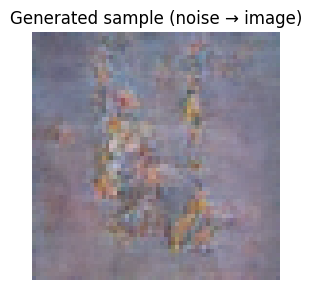

Image pixel range: 0.2728636860847473 → 0.837614119052887


In [4]:
# ── FIX: use model.eval() + torch.no_grad() explicitly ───────────────
image_size = config['image_size']

@torch.no_grad()
def generate_image_from_noise(model, diffusion, image_size, device, noise=None):
    """Returns a single generated image tensor in [0,1] shape (H, W, 3)."""
    if noise is None:
        noise = torch.randn(1, 3, image_size, image_size, device=device)
    # FIX: call sample_from_given_noise (runs full T→0 loop)
    generated = diffusion.sample_from_given_noise(model, noise)
    # denormalize from [-1,1] → [0,1] then move to CPU
    return denormalize(generated)[0].cpu()

generated = generate_image_from_noise(model, diffusion, image_size, device)

plt.figure(figsize=(3, 3))
plt.imshow(generated.permute(1, 2, 0).clamp(0, 1).numpy())
plt.axis('off')
plt.title('Generated sample (noise → image)')
plt.tight_layout()
plt.show()
print('Image pixel range:', generated.min().item(), '→', generated.max().item())

## 2. Visualize Full Reverse Trajectory (noise → image)
Shows 10 frames from the 1000-step denoising process.

**What you should see:** The first frame (step 0) is pure colorful noise.
By step 1000 it should look like a blurry animal image.

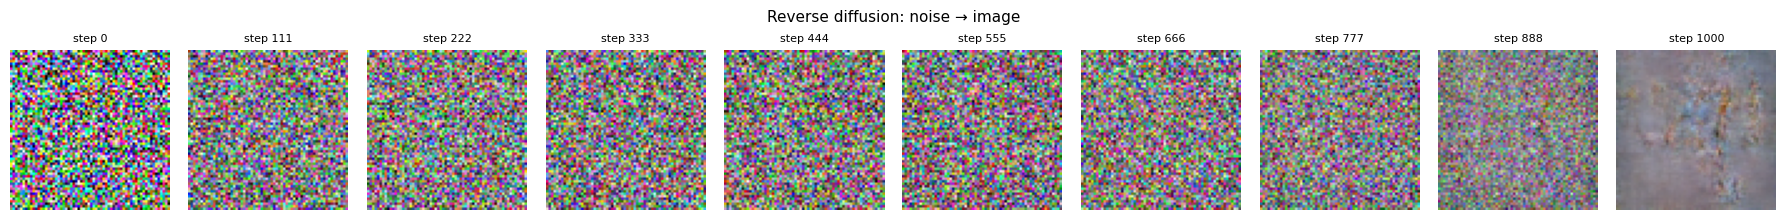

Saved reverse_diffusion_trajectory.png


In [5]:
@torch.no_grad()
def generate_with_trajectory(model, diffusion, image_size, device, num_shown=10):
    noise = torch.randn(1, 3, image_size, image_size, device=device)
    # return_all_steps=True gives us ALL 1001 intermediate images
    final_img, all_steps = diffusion.sample_from_given_noise(
        model, noise, return_all_steps=True
    )
    total_steps = len(all_steps)              # 1001  (step 0 … step 1000)
    idxs = torch.linspace(0, total_steps - 1, num_shown).long().tolist()
    chosen = [all_steps[i] for i in idxs]
    return chosen, idxs, final_img

chosen_steps, idxs, final_img = generate_with_trajectory(
    model, diffusion, image_size, device, num_shown=10
)

fig, axes = plt.subplots(1, len(chosen_steps), figsize=(len(chosen_steps) * 1.8, 2.2))
for ax, step_img, step_idx in zip(axes, chosen_steps, idxs):
    # step_img shape: (1, 3, H, W)  — single image from batch
    vis = denormalize(step_img[0]).permute(1, 2, 0).clamp(0, 1).numpy()
    ax.imshow(vis)
    ax.set_title(f'step {step_idx}', fontsize=8)
    ax.axis('off')
fig.suptitle('Reverse diffusion: noise → image', fontsize=11)
plt.tight_layout()
plt.savefig('reverse_diffusion_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved reverse_diffusion_trajectory.png')

## 3. Generate a Batch / Grid of Samples
Shows 8 independently generated images — good for the report.

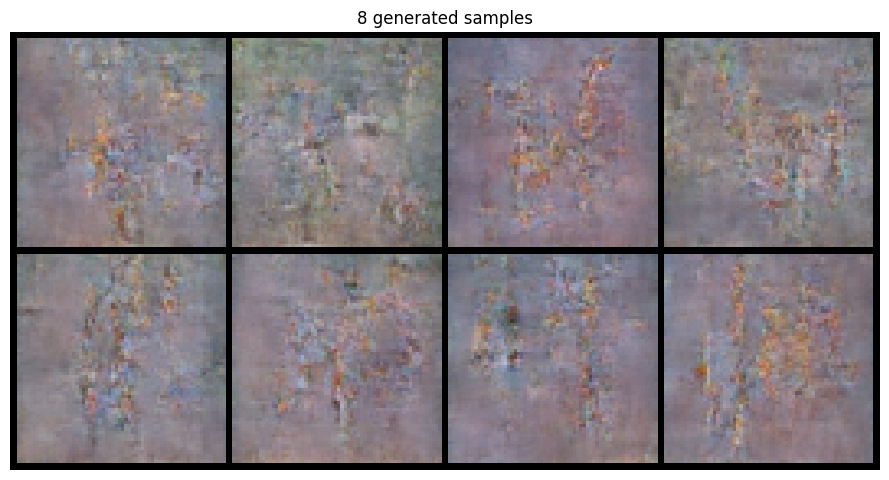

Saved generated_batch.png


In [6]:
NUM_SAMPLES = 8

@torch.no_grad()
def generate_batch(model, diffusion, image_size, num_samples, device):
    shape = (num_samples, 3, image_size, image_size)
    samples = diffusion.p_sample_loop(model, shape, device)
    return denormalize(samples).cpu()

batch = generate_batch(model, diffusion, image_size, NUM_SAMPLES, device)
grid = make_grid(batch, nrow=4)

plt.figure(figsize=(9, 5))
plt.imshow(grid.permute(1, 2, 0).clamp(0, 1).numpy())
plt.axis('off')
plt.title(f'{NUM_SAMPLES} generated samples')
plt.tight_layout()
plt.savefig('generated_batch.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved generated_batch.png')

## 4. Reproducible Generation with Fixed Seed

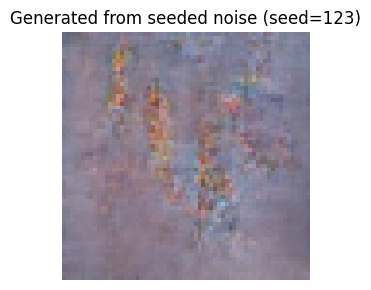

In [7]:
torch.manual_seed(123)
custom_noise = torch.randn(1, 3, image_size, image_size, device=device)
custom_generated = generate_image_from_noise(
    model, diffusion, image_size, device, noise=custom_noise
)

plt.figure(figsize=(3, 3))
plt.imshow(custom_generated.permute(1, 2, 0).clamp(0, 1).numpy())
plt.axis('off')
plt.title('Generated from seeded noise (seed=123)')
plt.tight_layout()
plt.show()